In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, Markdown

# Estilo visual
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [2]:
nRowsRead = None  # Cambia a None si quieres leer todo el archivo

df1 = pd.read_csv('finanzas.csv', delimiter=',', nrows=nRowsRead)
df1.dataframeName = 'finanzas.csv'
nRow, nCol = df1.shape

print(f'There are {nRow} rows and {nCol} columns')
df1.head()   # Muestra las primeras filas

There are 6362620 rows and 11 columns


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
# Reporte de dimensiones y información del dataset
print("=== REPORTE DEL DATASET ===")
print(f"Número de filas:    {nRow:,}")
print(f"Número de columnas: {nCol}")
print(f"Tamaño total:       {nRow} filas × {nCol} columnas\n")

# Tamaño en memoria
memory_usage = df1.memory_usage(deep=True).sum()
print(f"Tamaño en memoria:  {memory_usage / 1024**2:.2f} MB\n")

# Tipos de datos de cada columna
print("Columnas y tipos de datos:")
print(df1.dtypes)

=== REPORTE DEL DATASET ===
Número de filas:    6,362,620
Número de columnas: 11
Tamaño total:       6362620 filas × 11 columnas

Tamaño en memoria:  1452.57 MB

Columnas y tipos de datos:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


# 2. Muestreo Estratégico

Dado que el dataset original contiene más de **6.3 millones de registros**, se decidió trabajar con una **muestra aleatoria de 100,000 registros** para agilizar el análisis exploratorio y la preparación de datos, manteniendo la reproducibilidad con `random_state=42`.

Esto es una práctica estándar en proyectos de Data Science cuando se trabaja con datasets muy grandes.

In [4]:
print(f"Dataset cargado: {nRow:,} filas y {nCol} columnas\n")

# Extraer muestra si es necesario
if nRow > 100_000:
    df = df1.sample(n=100_000, random_state=42).reset_index(drop=True)
    print(f"→ Se ha extraído una muestra aleatoria de 100,000 registros (random_state=42)")
else:
    df = df1.copy()
    print("→ El dataset tiene 100,000 filas o menos, se utiliza completo.")

print(f"Dataset final para trabajar: {df.shape[0]:,} filas y {df.shape[1]} columnas")

Dataset cargado: 6,362,620 filas y 11 columnas

→ Se ha extraído una muestra aleatoria de 100,000 registros (random_state=42)
Dataset final para trabajar: 100,000 filas y 11 columnas


# 2.1 Detección y Manejo de Valores Nulos

Se analizó la presencia de valores nulos en el dataset y se aplicaron estrategias de imputación según el tipo de variable y Se verificó la existencia de registros duplicados exactos.

In [6]:
# Reporte de valores nulos
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(4)

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values('Nulos', ascending=False)

print(reporte_nulos)

# analisis de duplicados
duplicados = df.duplicated().sum()
porcentaje_dup = (duplicados / len(df) * 100).round(4)

print(f"Filas duplicadas exactas: {duplicados:,}")
print(f"Porcentaje del total: {porcentaje_dup}%")
    
print(f"Dimensiones después de eliminar duplicados: {df.shape[0]:,} filas")

                Nulos  Porcentaje (%)
step                0             0.0
type                0             0.0
amount              0             0.0
nameOrig            0             0.0
oldbalanceOrg       0             0.0
newbalanceOrig      0             0.0
nameDest            0             0.0
oldbalanceDest      0             0.0
newbalanceDest      0             0.0
isFraud             0             0.0
isFlaggedFraud      0             0.0
Filas duplicadas exactas: 0
Porcentaje del total: 0.0%
Dimensiones después de eliminar duplicados: 100,000 filas


# 2.3 Verificación y Optimización de Tipos de Datos

Se revisaron los tipos de datos de cada columna y se realizaron conversiones para optimizar el uso de memoria.

In [17]:
print("Tipos de datos actuales:")
print(df.dtypes)

# Identificar posibles problemas
print("\nAnálisis de tipos:")
# Variables que deberían ser numéricas pero están como object
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            # Intentar convertir a numérico
            pd.to_numeric(df[col], errors='coerce')
            print(f"• {col}: Es texto pero parece numérico → Posible conversión recomendada")
        except:
            pass
# Conversión explícita si es necesario (ajusta según tu dataset)
# Ejemplo: Si 'step' debería ser entero

# Optimización de tipos (recomendado)
df['isFraud'] = df['isFraud'].astype('int8')
df['isFlaggedFraud'] = df['isFlaggedFraud'].astype('int8')

print("\nTipos de datos después de conversiones:")
print(df.dtypes)

Tipos de datos actuales:
step                int32
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud              int8
isFlaggedFraud       int8
dtype: object

Análisis de tipos:

Tipos de datos después de conversiones:
step                int32
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud              int8
isFlaggedFraud       int8
dtype: object


# 2.4 Detección de Valores Imposibles e Inconsistencias

Se identificaron posibles inconsistencias lógicas en las variables financieras (montos negativos, balances inconsistentes, etc.).

In [42]:
# 1. Montos negativos (imposible en transacciones)
monto_negativo = (df['amount'] < 0).sum()
print(f"1. Montos negativos (amount < 0): {monto_negativo:,} casos")

# 2. Balances negativos en origen (puede ser posible en sobregiro, pero raro)
oldbalance_neg = (df['oldbalanceOrg'] < 0).sum()
newbalance_neg = (df['newbalanceOrig'] < 0).sum()
print(f"2. oldbalanceOrg negativo     : {oldbalance_neg:,} casos")
print(f"3. newbalanceOrig negativo    : {newbalance_neg:,} casos")

# 3. Balances negativos en destino
oldbalance_dest_neg = (df['oldbalanceDest'] < 0).sum()
newbalance_dest_neg = (df['newbalanceDest'] < 0).sum()
print(f"4. oldbalanceDest negativo    : {oldbalance_dest_neg:,} casos")
print(f"5. newbalanceDest negativo    : {newbalance_dest_neg:,} casos")

# 4. Inconsistencias matemáticas (muy importante)
# newbalanceOrig debería ser ≈ oldbalanceOrg - amount (en la mayoría de tipos)
df['diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
inconsistencia_orig = (abs(df['diff_orig'] - df['amount']) > 1).sum()  # tolerancia de 1 unidad

print(f"6. Inconsistencias en balance origen (old - new != amount): {inconsistencia_orig:,} casos")

# 5. Resumen por tipo de transacción
print("\n--- Inconsistencias por tipo de transacción ---")
inconsistencias_por_tipo = df.groupby('type').apply(
    lambda x: (abs(x['oldbalanceOrg'] - x['newbalanceOrig'] - x['amount']) > 1).sum()
)
print(inconsistencias_por_tipo)

1. Montos negativos (amount < 0): 0 casos
2. oldbalanceOrg negativo     : 0 casos
3. newbalanceOrig negativo    : 0 casos
4. oldbalanceDest negativo    : 0 casos
5. newbalanceDest negativo    : 0 casos
6. Inconsistencias en balance origen (old - new != amount): 78,811 casos

--- Inconsistencias por tipo de transacción ---
type
CASH_IN     22141
CASH_OUT    31355
DEBIT         185
PAYMENT     17181
TRANSFER     7949
dtype: int64


In [45]:
# Crear tabla resumen de calidad
resumen_calidad = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': df.dtypes.values,
    'Nulos (%)': (df.isnull().sum() / len(df) * 100).round(4),
    'Inconsistencias': [0]*len(df.columns)  # Se actualiza manualmente
})

# Actualizar inconsistencias específicas
resumen_calidad.loc[resumen_calidad['Variable'].isin(['oldbalanceOrg', 'newbalanceOrig']), 'Inconsistencias'] = 78811

print(resumen_calidad.to_string(index=False))

      Variable    Tipo  Nulos (%)  Inconsistencias
          step   int32        0.0                0
          type     str        0.0                0
        amount float64        0.0                0
      nameOrig     str        0.0                0
 oldbalanceOrg float64        0.0            78811
newbalanceOrig float64        0.0            78811
      nameDest     str        0.0                0
oldbalanceDest float64        0.0                0
newbalanceDest float64        0.0                0
       isFraud    int8        0.0                0
isFlaggedFraud    int8        0.0                0
     diff_orig float64        0.0                0


# 3. Estadística Descriptiva

En esta sección se realiza un análisis exhaustivo de la distribución de las variables numéricas y categóricas, con el objetivo de extraer insights iniciales del dataset.

## 3.1 y 3.2 Estadísticos Descriptivos e Interpretación de Variables Numéricas

Se calcularon medidas de tendencia central, dispersión, asimetría y curtosis. Además se interpretaron los resultados.

In [8]:
# Seleccionamos solo columnas numéricas
numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculamos estadísticos base + adicionales
desc = df[numericas].describe().round(2)

# Agregamos métricas adicionales
desc.loc['cv'] = (df[numericas].std() / df[numericas].mean()).round(4)      # Coeficiente de Variación
desc.loc['skew'] = df[numericas].skew().round(4)                           # Asimetría
desc.loc['kurtosis'] = df[numericas].kurtosis().round(4)                   # Curtosis

print(desc.T)  # Transpuesto para mejor visualización

                   count        mean         std   min       25%        50%  \
step            100000.0      243.71      142.52  1.00    156.00     240.00   
amount          100000.0   180581.10   558669.94  0.92  13508.21   76030.86   
oldbalanceOrg   100000.0   836680.38  2901104.19  0.00      0.00   13938.50   
newbalanceOrig  100000.0   858223.42  2936798.68  0.00      0.00       0.00   
oldbalanceDest  100000.0  1104192.82  3223011.12  0.00      0.00  138748.17   
newbalanceDest  100000.0  1230054.90  3475325.62  0.00      0.00  218578.62   
isFraud         100000.0        0.00        0.04  0.00      0.00       0.00   
isFlaggedFraud  100000.0        0.00        0.00  0.00      0.00       0.00   

                       75%           max        cv      skew     kurtosis  
step                335.00  7.360000e+02    0.5848    0.3773       0.3296  
amount           209113.02  3.697390e+07    3.0937   22.2188     890.4593  
oldbalanceOrg    107077.12  3.359321e+07    3.4674    5.2513

In [9]:
print("\n3.2 Interpretación de Variables Numéricas:")

for col in numericas:
    mean = df[col].mean()
    median = df[col].median()
    cv = (df[col].std() / mean) if mean != 0 else 0
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    
    print(f"\n→ {col.upper()}:")
    print(f"   Media: {mean:,.2f} | Mediana: {median:,.2f}")
    
    if abs(mean - median) / mean > 0.1:
        print("   ⚠️  Media y mediana DIFEREN muy significativamente → Distribución asimétrica")
    else:
        print("   Media y mediana cercanas → Distribución relativamente simétrica")
    
    print(f"   CV: {cv:.4f} → {'Alta variabilidad' if cv > 1 else 'Moderada/Baja variabilidad'}")
    
    if skew > 1 or skew < -1:
        print(f"   ⚠️  Asimetría FUERTE (skew = {skew:.2f})")
    if kurt > 3:
        print(f"   ⚠️  Curtosis alta (colas pesadas) = {kurt:.2f}")


3.2 Interpretación de Variables Numéricas:

→ STEP:
   Media: 243.71 | Mediana: 240.00
   Media y mediana cercanas → Distribución relativamente simétrica
   CV: 0.5848 → Moderada/Baja variabilidad

→ AMOUNT:
   Media: 180,581.10 | Mediana: 76,030.86
   ⚠️  Media y mediana DIFEREN muy significativamente → Distribución asimétrica
   CV: 3.0937 → Alta variabilidad
   ⚠️  Asimetría FUERTE (skew = 22.22)
   ⚠️  Curtosis alta (colas pesadas) = 890.46

→ OLDBALANCEORG:
   Media: 836,680.38 | Mediana: 13,938.50
   ⚠️  Media y mediana DIFEREN muy significativamente → Distribución asimétrica
   CV: 3.4674 → Alta variabilidad
   ⚠️  Asimetría FUERTE (skew = 5.25)
   ⚠️  Curtosis alta (colas pesadas) = 32.88

→ NEWBALANCEORIG:
   Media: 858,223.42 | Mediana: 0.00
   ⚠️  Media y mediana DIFEREN muy significativamente → Distribución asimétrica
   CV: 3.4220 → Alta variabilidad
   ⚠️  Asimetría FUERTE (skew = 5.18)
   ⚠️  Curtosis alta (colas pesadas) = 32.06

→ OLDBALANCEDEST:
   Media: 1,104,192.8


Generando gráficos de interpretación (3.2)...


C:\Users\Joseph\AppData\Local\Temp\ipykernel_21516\2369527089.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cv_values.index, y=cv_values.values, ax=axes[0,0], palette='Blues_d')
C:\Users\Joseph\AppData\Local\Temp\ipykernel_21516\2369527089.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skew_values.index, y=skew_values.values, ax=axes[0,1], palette='Reds_d')
C:\Users\Joseph\AppData\Local\Temp\ipykernel_21516\2369527089.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kurt_values.index, y=kurt_values.values, ax=axes[1,0]

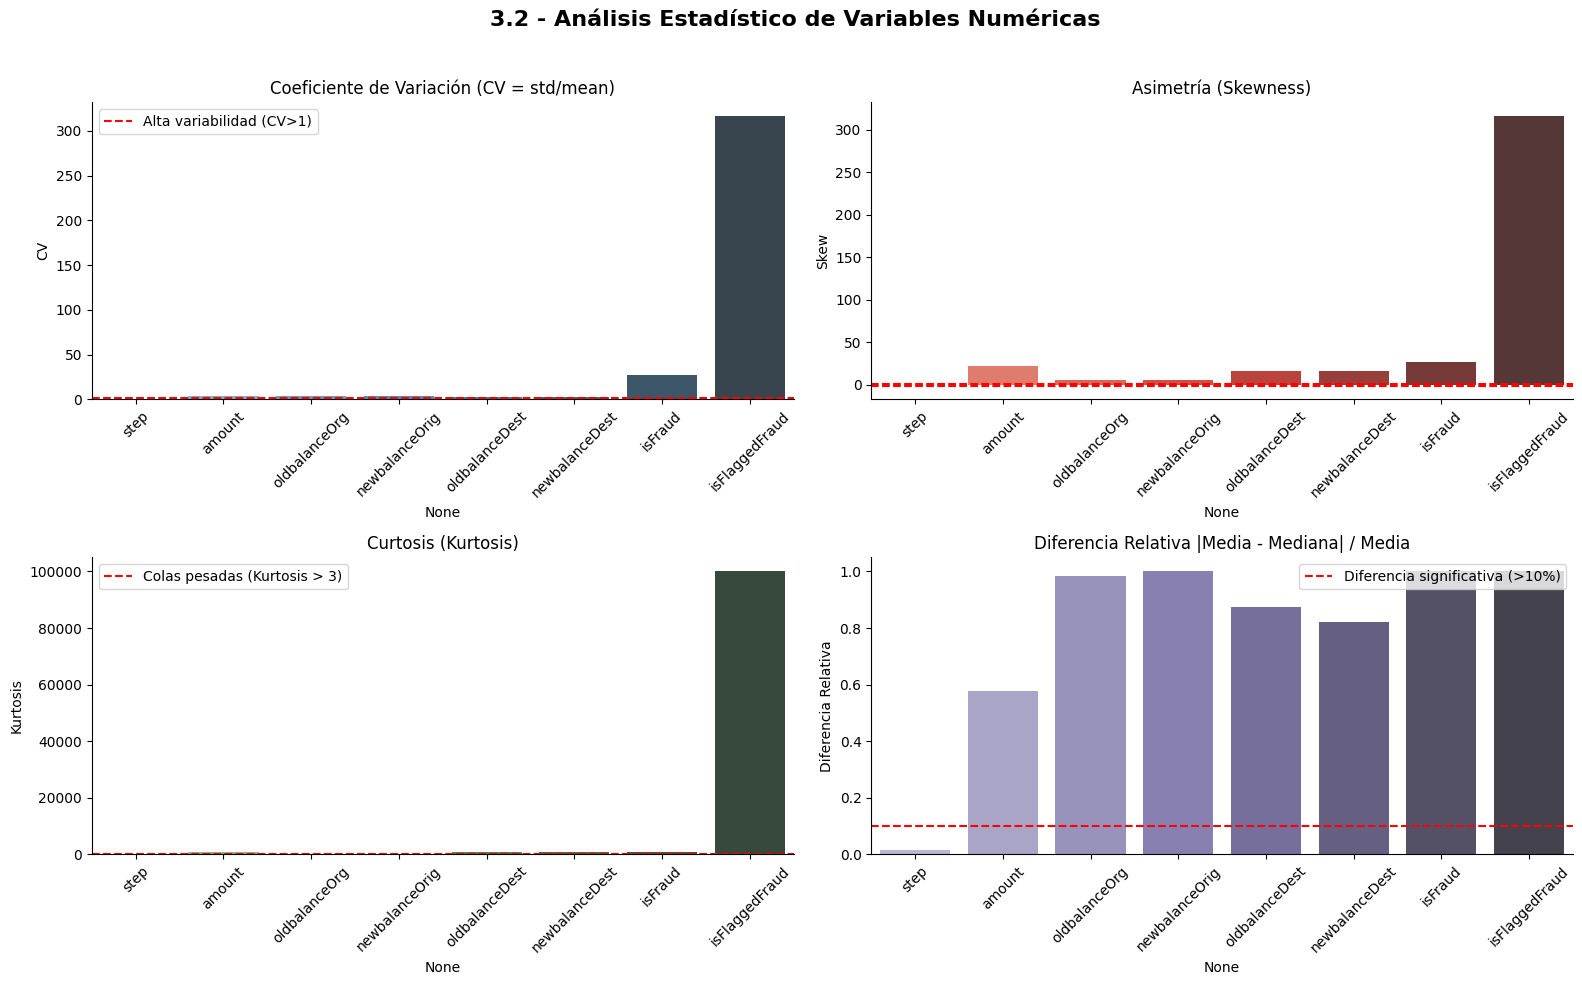

In [ ]:
# ====================== GRÁFICO 3.2 - ESTADÍSTICA DESCRIPTIVA ======================
print("\nGenerando gráficos de interpretación (3.2)...")

numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('3.2 - Análisis Estadístico de Variables Numéricas', fontsize=16, fontweight='bold')

# 1. Coeficiente de Variación (CV)
cv_values = (df[numericas].std() / df[numericas].mean()).fillna(0)
sns.barplot(x=cv_values.index, y=cv_values.values, ax=axes[0,0], palette='Blues_d')
axes[0,0].set_title('Coeficiente de Variación (CV = std/mean)')
axes[0,0].set_ylabel('CV')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(y=1, color='red', linestyle='--', label='Alta variabilidad (CV>1)')
axes[0,0].legend()

# 2. Asimetría (Skewness)
skew_values = df[numericas].skew()
sns.barplot(x=skew_values.index, y=skew_values.values, ax=axes[0,1], palette='Reds_d')
axes[0,1].set_title('Asimetría (Skewness)')
axes[0,1].set_ylabel('Skew')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].axhline(y=1, color='red', linestyle='--')
axes[0,1].axhline(y=-1, color='red', linestyle='--')

# 3. Curtosis (Kurtosis)
kurt_values = df[numericas].kurtosis()
sns.barplot(x=kurt_values.index, y=kurt_values.values, ax=axes[1,0], palette='Greens_d')
axes[1,0].set_title('Curtosis (Kurtosis)')
axes[1,0].set_ylabel('Kurtosis')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].axhline(y=3, color='red', linestyle='--', label='Colas pesadas (Kurtosis > 3)')
axes[1,0].legend()

# 4. Diferencia Media vs Mediana (relativa)
diff_rel = abs(df[numericas].mean() - df[numericas].median()) / df[numericas].mean()
sns.barplot(x=diff_rel.index, y=diff_rel.values, ax=axes[1,1], palette='Purples_d')
axes[1,1].set_title('Diferencia Relativa |Media - Mediana| / Media')
axes[1,1].set_ylabel('Diferencia Relativa')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].axhline(y=0.1, color='red', linestyle='--', label='Diferencia significativa (>10%)')
axes[1,1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 3.3 Análisis de Variables Categóricas

In [13]:
# ====================== 3.3 Variables Categóricas (VERSIÓN MEJORADA) ======================
print("\n3.3 Análisis de Variables Categóricas:")

categoricas = df.select_dtypes(include=['str']).columns.tolist()

for col in categoricas:
    unique_count = df[col].nunique()
    print(f"\n→ Variable: {col}")
    print(f"   Categorías únicas: {unique_count:,} ({unique_count/len(df)*100:.2f}% del total)")
    
    if unique_count > 100:  # Alta cardinalidad (como IDs)
        print("   → Alta cardinalidad (posible ID). Se muestra solo top 10:")
        distrib = df[col].value_counts().head(10)
        print(distrib)
        print(f"   → Representan el {distrib.sum()/len(df)*100:.2f}% de las transacciones")
        
        # Porcentaje de valores únicos
        print(f"   → Porcentaje de valores únicos: {unique_count/len(df)*100:.2f}%")
        
    else:  # Baja cardinalidad (como 'type')
        print("   Distribución:")
        distrib = (df[col].value_counts(normalize=True) * 100).round(2)
        print(distrib)
        
        # Categorías poco representadas
        bajas = distrib[distrib < 1]
        if len(bajas) > 0:
            print(f"   ⚠️  Categorías con menos del 1%: {len(bajas)}")


3.3 Análisis de Variables Categóricas:

→ Variable: type
   Categorías únicas: 5 (0.01% del total)
   Distribución:
type
CASH_OUT    35.33
PAYMENT     33.56
CASH_IN     22.14
TRANSFER     8.35
DEBIT        0.61
Name: proportion, dtype: float64
   ⚠️  Categorías con menos del 1%: 1

→ Variable: nameOrig
   Categorías únicas: 99,999 (100.00% del total)
   → Alta cardinalidad (posible ID). Se muestra solo top 10:
nameOrig
C838212175     2
C632336343     1
C1264712553    1
C1746846248    1
C333676753     1
C813403091     1
C2002954533    1
C813757373     1
C1850864812    1
C886849972     1
Name: count, dtype: int64
   → Representan el 0.01% de las transacciones
   → Porcentaje de valores únicos: 100.00%

→ Variable: nameDest
   Categorías únicas: 92,914 (92.91% del total)
   → Alta cardinalidad (posible ID). Se muestra solo top 10:
nameDest
C1085553281    6
C1657041838    5
C1269097316    5
C1040847151    5
C1849014975    5
C709091500     5
C1009406898    5
C1495761010    5
C1674899618   

## 3.4 Análisis de la Variable Objetivo (`isFraud`)

Se evaluó el nivel de desbalanceo de la variable objetivo, aspecto crítico para futuros modelos de detección de fraude.

In [11]:
# ====================== 3.4 Variable Objetivo (isFraud) ======================
print("\n3.4 Prevalencia de la Variable Objetivo (isFraud)")

fraude = df['isFraud'].value_counts()
fraude_pct = df['isFraud'].value_counts(normalize=True) * 100

print(pd.DataFrame({
    'Cantidad': fraude,
    'Porcentaje (%)': fraude_pct.round(4)
}))

print(f"\n→ El dataset está **altamente desbalanceado** ({fraude_pct[1]:.4f}% de fraude)")


3.4 Prevalencia de la Variable Objetivo (isFraud)
         Cantidad  Porcentaje (%)
isFraud                          
0           99859          99.859
1             141           0.141

→ El dataset está **altamente desbalanceado** (0.1410% de fraude)



Generando gráfico de la variable objetivo (isFraud)...


C:\Users\Joseph\AppData\Local\Temp\ipykernel_21516\2439086887.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='isFraud', ax=axes[0], palette=['#2E8B57', '#FF6B6B'])
C:\Users\Joseph\AppData\Local\Temp\ipykernel_21516\2439086887.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraude_pct.index, y=fraude_pct.values, ax=axes[1], palette=['#2E8B57', '#FF6B6B'])


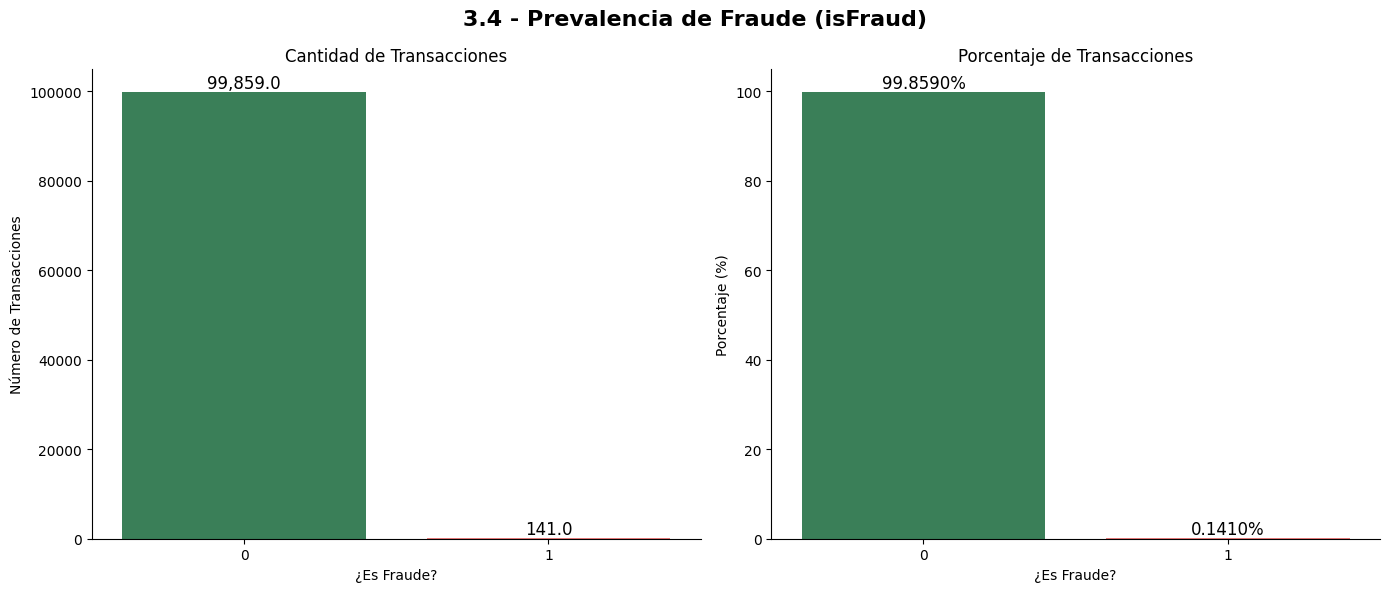

In [18]:

# ====================== GRÁFICO 3.4 - VARIABLE OBJETIVO ======================
print("\nGenerando gráfico de la variable objetivo (isFraud)...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('3.4 - Prevalencia de Fraude (isFraud)', fontsize=16, fontweight='bold')

# Gráfico 1: Conteo absoluto
sns.countplot(data=df, x='isFraud', ax=axes[0], palette=['#2E8B57', '#FF6B6B'])
axes[0].set_title('Cantidad de Transacciones')
axes[0].set_xlabel('¿Es Fraude?')
axes[0].set_ylabel('Número de Transacciones')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,}', 
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Gráfico 2: Porcentaje
fraude_pct = df['isFraud'].value_counts(normalize=True) * 100
sns.barplot(x=fraude_pct.index, y=fraude_pct.values, ax=axes[1], palette=['#2E8B57', '#FF6B6B'])
axes[1].set_title('Porcentaje de Transacciones')
axes[1].set_xlabel('¿Es Fraude?')
axes[1].set_ylabel('Porcentaje (%)')

# Etiquetas en barras de porcentaje
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.4f}%', 
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

## Interpretación de las Variables con Mayor Variabilidad

Las **tres variables con mayor variabilidad** (medido mediante el **Coeficiente de Variación**) son:

| Posición | Variable           | CV      | Nivel de Variabilidad |
|----------|--------------------|---------|-----------------------|
| 1°       | **oldbalanceOrg**  | 3.4674  | Muy Alta              |
| 2°       | **newbalanceOrig** | 3.4220  | Muy Alta              |
| 3°       | **amount**         | 3.0937  | Muy Alta              |

### Explicación en el contexto del negocio (Detección de Fraude):

1. **oldbalanceOrg (Saldo anterior de la cuenta de origen)**  
   Es la variable con mayor dispersión. Esto indica que las transacciones se originan desde cuentas con saldos muy diferentes (desde casi cero hasta varios millones).  
   En el contexto de fraude, los atacantes suelen seleccionar cuentas con saldos altos, por lo que esta alta variabilidad refleja la heterogeneidad de los clientes.

2. **newbalanceOrig (Saldo resultante de la cuenta de origen)**  
   Muestra una variabilidad muy similar. Refleja que después de la transacción, los saldos finales también varían enormemente.  
   Las inconsistencias entre `oldbalanceOrg` y `newbalanceOrig` son frecuentes y constituyen una **señal importante** para detectar posibles fraudes.

3. **amount (Monto de la transacción)**  
   Los montos presentan una distribución muy asimétrica (la mayoría son moderados, pero existen transacciones extremadamente grandes).  
   En el negocio bancario, los montos altos suelen ser los más riesgosos y son los que más se monitorean para prevenir fraudes.

### Conclusión:
La alta variabilidad en estas tres variables es **esperada** en un dataset de transacciones reales, ya que refleja la diversidad de clientes y comportamientos. Sin embargo, esta variabilidad, junto con la fuerte asimetría y las inconsistencias en balances, proporciona información valiosa para identificar patrones anómalos asociados a actividades fraudulentas.